# H2 dissociation curve with VQE

Build the four-qubit Hamiltonian of H2 at each bond length, run VQE, and compare with Hartree-Fock and the exact answer. The code lives in `src/`.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
import matplotlib.pyplot as plt
import numpy as np

from src.h2_hamiltonian import h2_hamiltonian
from src.vqe import ansatz, dissociation_curve

In [2]:
h2 = h2_hamiltonian(0.735)
for pauli, coeff in zip(h2.qubit_op.paulis, h2.qubit_op.coeffs.real):
    print(f"{pauli}  {coeff:+.5f}")

IIII  -0.09058
IIIZ  +0.17218
IIZI  +0.17218
IZII  -0.22575
ZIII  -0.22575
IZIZ  +0.12091
IIZZ  +0.16893
YXXY  +0.04523
XXYY  -0.04523
YYXX  -0.04523
XYYX  +0.04523
ZIIZ  +0.16615
ZIZI  +0.12091
IZZI  +0.16615
ZZII  +0.17464


One parameter is enough here: the ground state only mixes |0011> (Hartree-Fock) with |1100> (both electrons in the antibonding orbital).

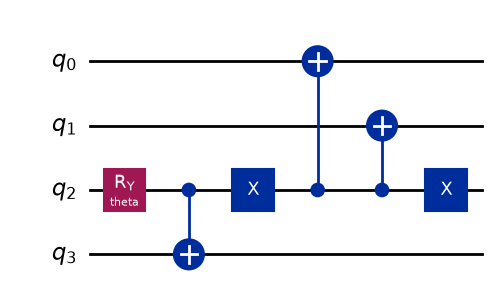

In [3]:
ansatz().draw("mpl")

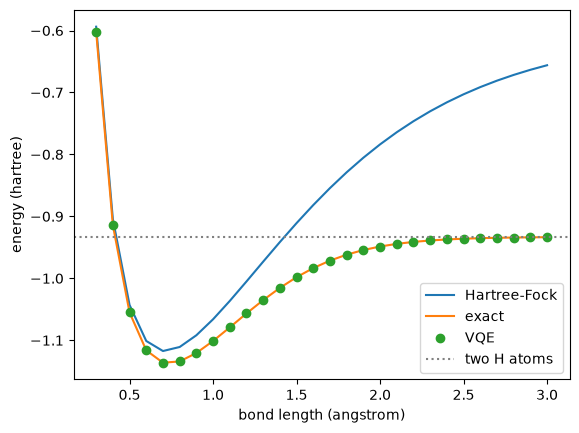

In [4]:
lengths = np.linspace(0.3, 3.0, 28)
results = dissociation_curve(list(lengths))

plt.plot(lengths, [r.hf_energy for r in results], label="Hartree-Fock")
plt.plot(lengths, [r.fci_energy for r in results], label="exact")
plt.plot(lengths, [r.energy for r in results], "o", label="VQE")
plt.axhline(2 * -0.466582, color="gray", linestyle=":", label="two H atoms")
plt.xlabel("bond length (angstrom)")
plt.ylabel("energy (hartree)")
plt.legend();

Hartree-Fock keeps both electrons paired in one orbital, which is wrong once the atoms pull apart. VQE with the two-determinant ansatz follows the exact curve all the way.